### 01. Using Custom GitHub Repository for Images



In [212]:
import os

REPO_URL = "https://github.com/toufiqimrose536-spec/CNN.git"
REPO_DIR = "/content/toufiqimrose_CNN"

if os.path.exists(REPO_DIR):
    print("Repository already exists.")
    print("Updating repository...")
    %cd {REPO_DIR}
    !git pull
else:
    print("Cloning repository...")
    !git clone {REPO_URL} {REPO_DIR}
    %cd {REPO_DIR}

print("\nRepository ready!")
print("Current directory:", os.getcwd())

Repository already exists.
Updating repository...
/content/toufiqimrose_CNN
Already up to date.

Repository ready!
Current directory: /content/toufiqimrose_CNN


### 02.  Update custom_dir to point to your custom images within the new repository structure

In [213]:
custom_dir = "CNN/Custom Images"

if not os.path.exists(custom_dir):
    raise FileNotFoundError(
        f"Custom images directory '{custom_dir}' was not found in the cloned repository."
    )

custom_files = [
    f for f in os.listdir(custom_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Custom images found:", len(custom_files))

for filename in sorted(custom_files):
    print(" -", filename)


Custom images found: 10
 - ankleboot.jpeg
 - bag.jpeg
 - coat.jpeg
 - dress.jpeg
 - pullover.jpeg
 - sandal.jpeg
 - shirt.jpeg
 - sneaker.jpeg
 - trouser.jpeg
 - tshirt.jpeg


### 03. Download and Load Fashion-MNIST Test CSV

In [214]:
# URL for the fashion-mnist_test.csv dataset
csv_url = "https://raw.githubusercontent.com/toufiqimrose536-spec/CNN/refs/heads/main/CNN/Dataset/fashion-mnist_test.csv"
csv_filename = "fashion-mnist_test.csv"

# Download the CSV file
print(f"Downloading {csv_filename}...")
!wget -O {csv_filename} {csv_url}
print(f"{csv_filename} downloaded successfully!")

# Load the CSV into a pandas DataFrame
import pandas as pd
test_df = pd.read_csv(csv_filename)

print("\nFirst 5 rows of the CSV dataset:")
display(test_df.head())

--2026-08-16 21:34:48--  https://raw.githubusercontent.com/toufiqimrose536-spec/CNN/refs/heads/main/CNN/Dataset/fashion-mnist_test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22176691 (21M) [text/plain]
Saving to: ‘fashion-mnist_test.csv’

fashion-mnist_test. 100%[===================>]  21.15M   106MB/s    in 0.2s    

2026-08-16 21:34:48 (106 MB/s) - ‘fashion-mnist_test.csv’ saved [22176691/22176691]

fashion-mnist_test.csv downloaded successfully!

First 5 rows of the CSV dataset:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 04. IMPORT LIBRARIES

In [215]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split

from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, accuracy_score

print("Libraries imported successfully!")

Libraries imported successfully!


### 05. DEVICE AND REPRODUCIBILITY

In [216]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


### 06. CLASS NAMES

In [217]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

NUM_CLASSES = len(classes)

print("Number of classes:", NUM_CLASSES)

for i, name in enumerate(classes):
    print(i, ":", name)

Number of classes: 10
0 : T-shirt/top
1 : Trouser
2 : Pullover
3 : Dress
4 : Coat
5 : Sandal
6 : Shirt
7 : Sneaker
8 : Bag
9 : Ankle boot


### 07. CUSTOM DATASET CHECK

In [218]:
custom_dir = "CNN/Custom Images"

if not os.path.exists(custom_dir):
    raise FileNotFoundError(
        f"Custom images directory '{custom_dir}' was not found in the cloned repository."
    )

custom_files = [
    f for f in os.listdir(custom_dir)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

print("Custom images found:", len(custom_files))

for filename in sorted(custom_files):
    print(" -", filename)


Custom images found: 10
 - ankleboot.jpeg
 - bag.jpeg
 - coat.jpeg
 - dress.jpeg
 - pullover.jpeg
 - sandal.jpeg
 - shirt.jpeg
 - sneaker.jpeg
 - trouser.jpeg
 - tshirt.jpeg


### 08. DISPLAY CUSTOM IMAGES

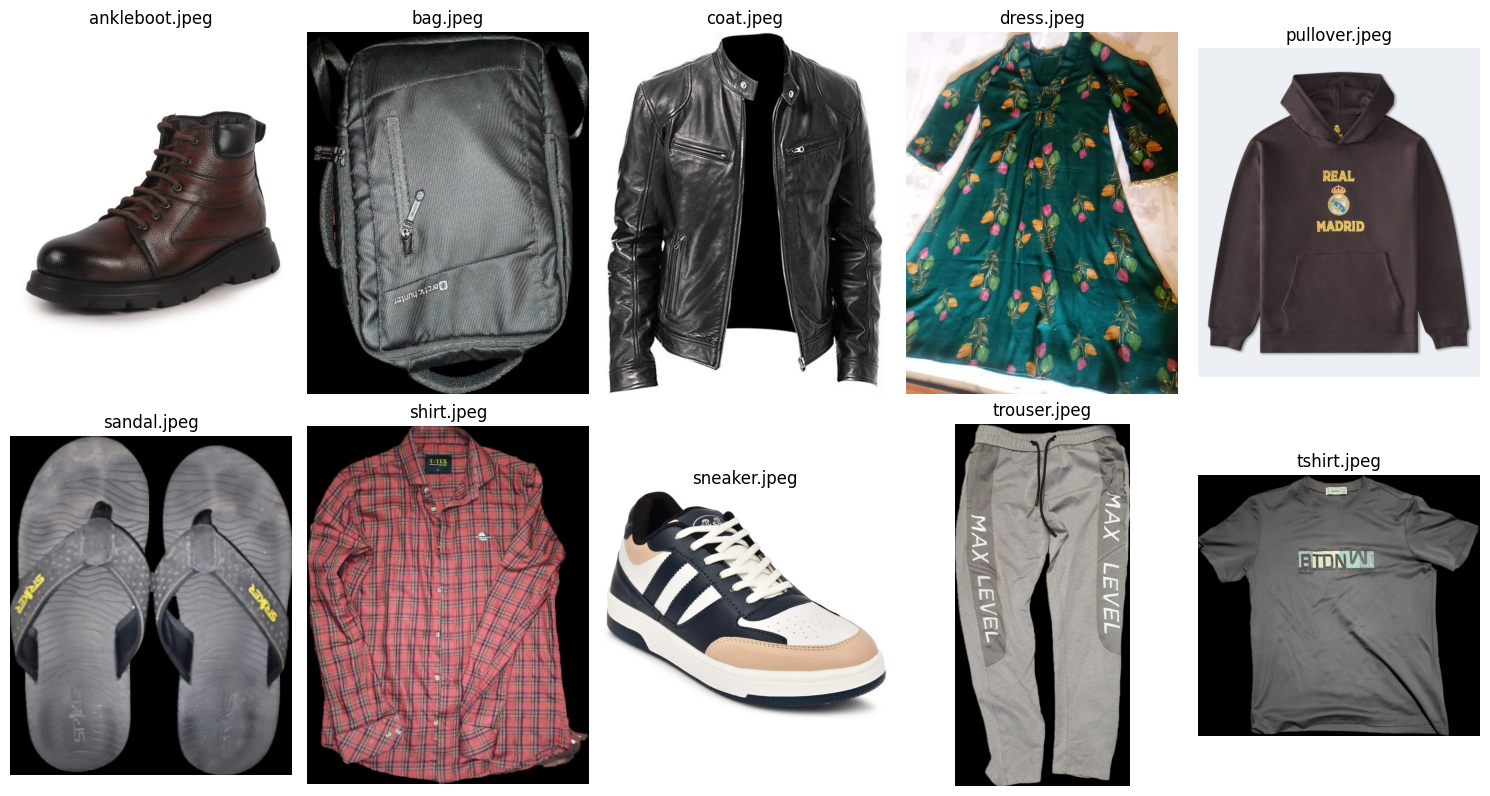

In [219]:
plt.figure(figsize=(15, 8))

for i, filename in enumerate(sorted(custom_files)):

    image_path = os.path.join(custom_dir, filename)
    image = Image.open(image_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(filename)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 09. IMAGE PREPROCESSING

In [220]:
IMAGE_SIZE = 28

MEAN = (0.5,)
STD = (0.5,)

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

custom_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

print("Transforms created successfully!")

Transforms created successfully!


### 10. DOWNLOAD FASHIONMNIST

In [221]:
train_dataset_full = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("FashionMNIST downloaded successfully!")
print("Training samples:", len(train_dataset_full))
print("Testing samples:", len(test_dataset))

FashionMNIST downloaded successfully!
Training samples: 60000
Testing samples: 10000


### 11. TRAIN / VALIDATION SPLIT

In [222]:
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

train_dataset, val_dataset = random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 48000
Validation samples: 12000
Testing samples: 10000


### 12. DATALOADERS

In [223]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

print("DataLoaders created!")

DataLoaders created!


### 13. VIEW TRAINING IMAGES

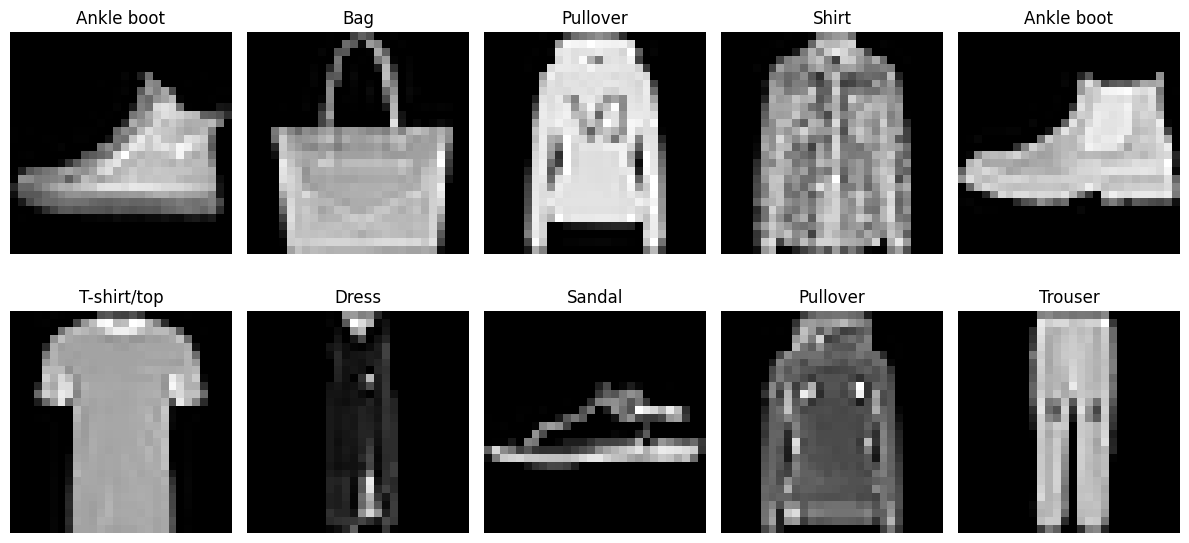

In [224]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))

for i in range(10):

    image = images[i].squeeze().numpy()

    # Undo normalization for visualization
    image = image * 0.5 + 0.5

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(classes[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

### 13. CNN MODEL

In [225]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.features = nn.Sequential(

            # First convolution block
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Second convolution block
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),

            nn.Linear(128, NUM_CLASSES)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


model = CNN().to(device)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


### 14. MODEL PARAMETERS

In [226]:
total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_parameters)
print("Trainable parameters:", trainable_parameters)

Total parameters: 421642
Trainable parameters: 421642


### 15. LOSS AND OPTIMIZER

In [227]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


### 16. TRAINING CONFIGURATION

In [228]:
NUM_EPOCHS = 10

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

print("Epochs:", NUM_EPOCHS)

Epochs: 10


### 17. TRAINING LOOP and Perform Traning

In [229]:
for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100.0 * correct / total


    # Validation
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            predictions = torch.argmax(outputs, dim=1)

            val_total += labels.size(0)
            val_correct += (
                predictions == labels
            ).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100.0 * val_correct / val_total


    # Save History

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # Print result

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [01/10] | Train Loss: 0.4670 | Train Acc: 83.16% | Val Loss: 0.3399 | Val Acc: 87.79%
Epoch [02/10] | Train Loss: 0.2935 | Train Acc: 89.38% | Val Loss: 0.2837 | Val Acc: 89.92%
Epoch [03/10] | Train Loss: 0.2449 | Train Acc: 91.09% | Val Loss: 0.2475 | Val Acc: 91.00%
Epoch [04/10] | Train Loss: 0.2111 | Train Acc: 92.32% | Val Loss: 0.2459 | Val Acc: 91.27%
Epoch [05/10] | Train Loss: 0.1878 | Train Acc: 93.13% | Val Loss: 0.2294 | Val Acc: 91.50%
Epoch [06/10] | Train Loss: 0.1613 | Train Acc: 94.05% | Val Loss: 0.2324 | Val Acc: 91.45%
Epoch [07/10] | Train Loss: 0.1434 | Train Acc: 94.62% | Val Loss: 0.2308 | Val Acc: 92.12%
Epoch [08/10] | Train Loss: 0.1222 | Train Acc: 95.46% | Val Loss: 0.2484 | Val Acc: 91.93%
Epoch [09/10] | Train Loss: 0.1042 | Train Acc: 96.09% | Val Loss: 0.2538 | Val Acc: 91.47%
Epoch [10/10] | Train Loss: 0.0888 | Train Acc: 96.80% | Val Loss: 0.2572 | Val Acc: 92.03%


### 18. LOSS GRAPH

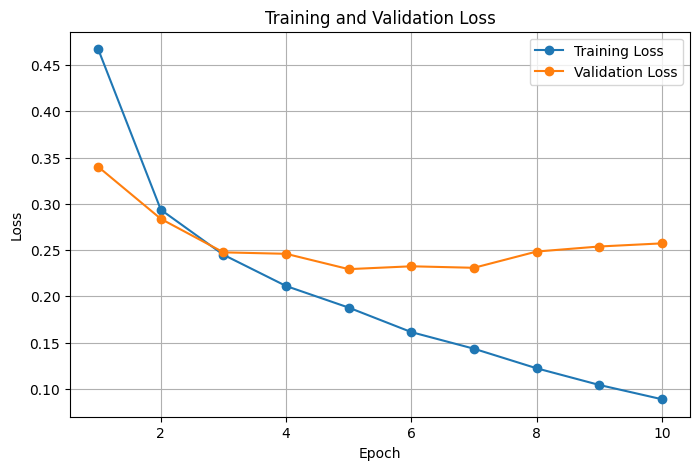

In [230]:
epochs = range(1, NUM_EPOCHS + 1)

# Check if losses lists are populated before plotting
if not train_losses or not val_losses:
    print("Training and validation losses are empty. Please ensure the training loop (Cell 16) has been executed successfully before attempting to plot the loss graph.")
else:
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        train_losses,
        marker="o",
        label="Training Loss"
    )

    plt.plot(
        epochs,
        val_losses,
        marker="o",
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")

    plt.legend()
    plt.grid(True)

    plt.show()


### 19. ACCURACY GRAPH

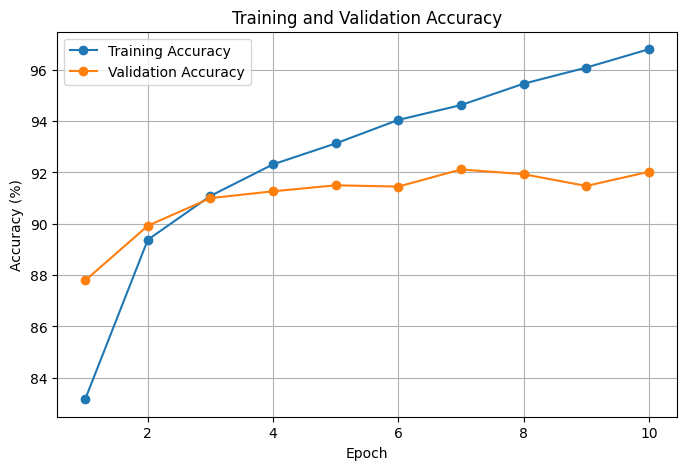

In [231]:
# Check if accuracies lists are populated before plotting
if not train_accuracies or not val_accuracies:
    print("Training and validation accuracies are empty. Please ensure the training loop (Cell 16) has been executed successfully before attempting to plot the accuracy graph.")
else:
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        train_accuracies,
        marker="o",
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        val_accuracies,
        marker="o",
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Training and Validation Accuracy")

    plt.legend()
    plt.grid(True)

    plt.show()


### 20. FINAL VALIDATION RESULT

In [232]:
print(
    f"Final Training Accuracy: "
    f"{train_accuracies[-1]:.2f}%"
)

print(
    f"Final Validation Accuracy: "
    f"{val_accuracies[-1]:.2f}%"
)

Final Training Accuracy: 96.80%
Final Validation Accuracy: 92.03%


### 21. TEST SET EVALUATION

In [233]:
model.eval()

all_predictions = []
all_labels = []

test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        test_total += labels.size(0)

        test_correct += (
            predictions == labels
        ).sum().item()

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

test_accuracy = 100.0 * test_correct / test_total

print(
    f"Test Accuracy: {test_accuracy:.2f}%"
)

Test Accuracy: 91.14%


### 22. CONFUSION MATRIX

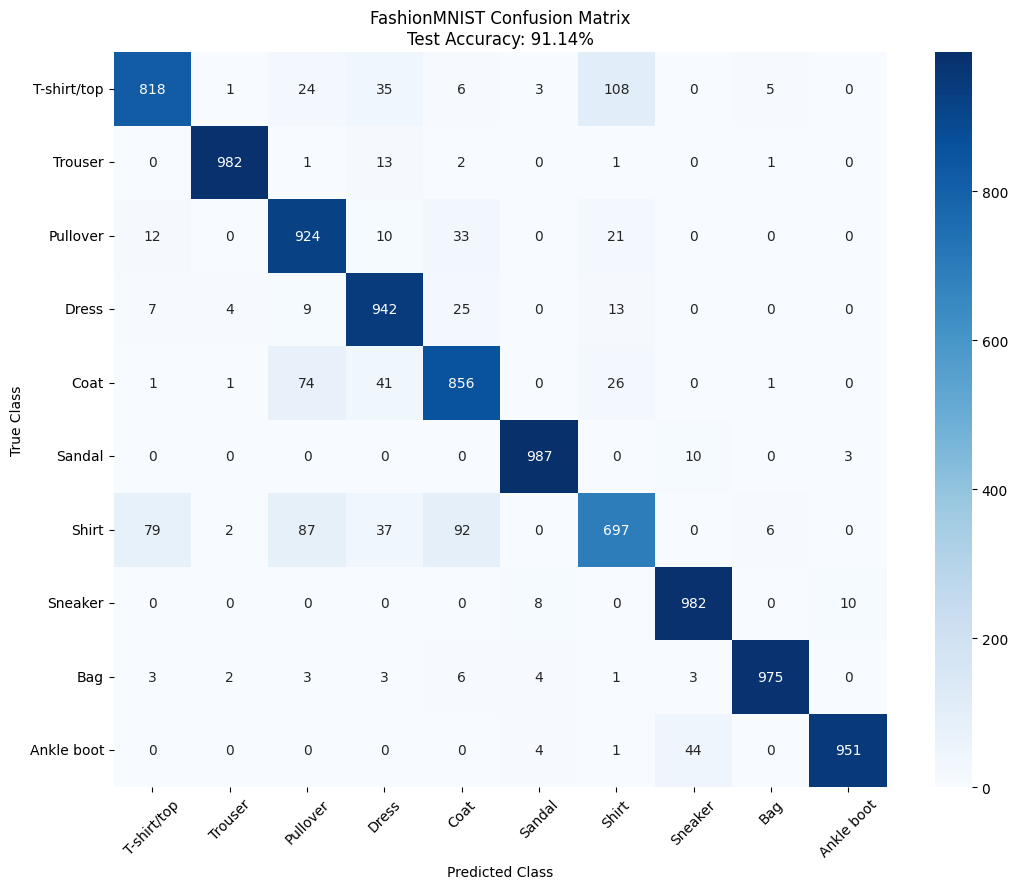

In [234]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(11, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.title(
    f"FashionMNIST Confusion Matrix\n"
    f"Test Accuracy: {test_accuracy:.2f}%"
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 23. NORMALIZED CONFUSION MATRIX

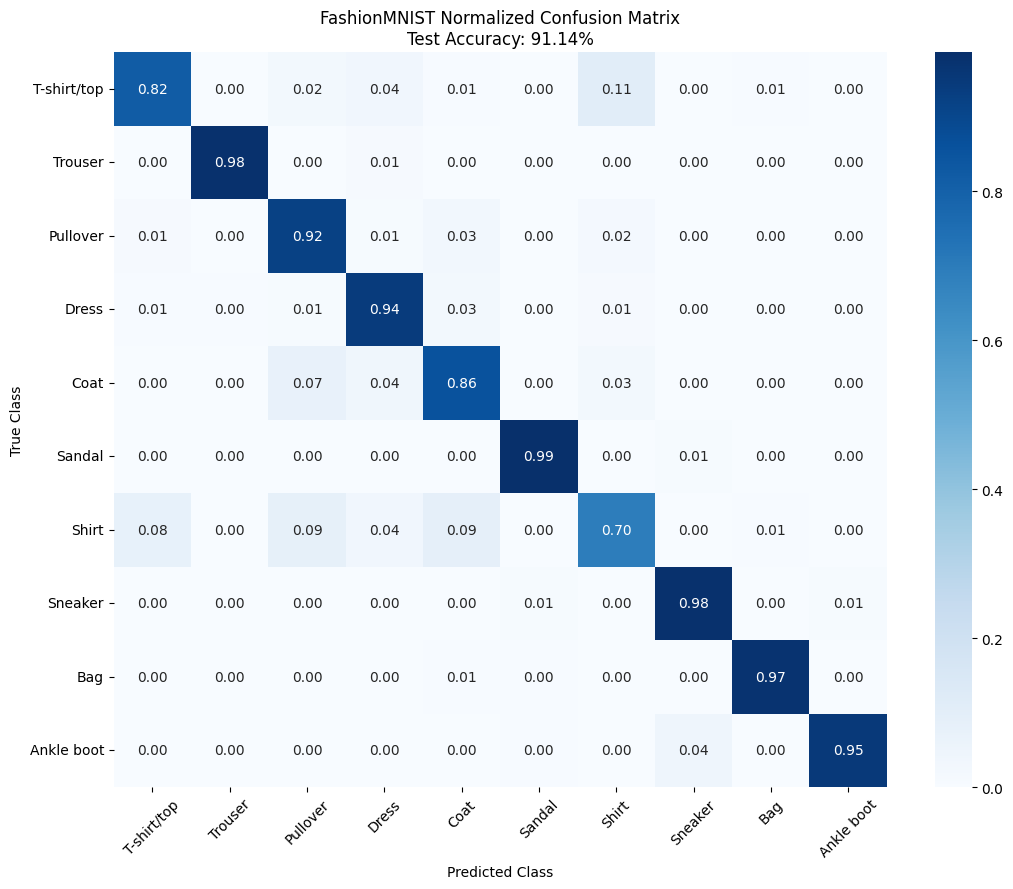

In [235]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(11, 9))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.title(
    f"FashionMNIST Normalized Confusion Matrix\n" +
    f"Test Accuracy: {test_accuracy:.2f}%"
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 24. PER-CLASS EVALUATION METRICS

In [236]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(
    all_labels,
    all_predictions,
    target_names=classes,
    output_dict=True # Return dictionary for easier display
)

# Convert to DataFrame for better visualization
report_df = pd.DataFrame(report).transpose()

# Format precision, recall, f1-score, and support
report_df[['precision', 'recall', 'f1-score']] = report_df[['precision', 'recall', 'f1-score']].applymap(lambda x: f"{x:.2f}")

# Display the report
print("\nPer-Class Evaluation Metrics (Standard Test Set):\n")
display(report_df.iloc[:-3]) # Exclude accuracy, macro avg, weighted avg for class-specific view



Per-Class Evaluation Metrics (Standard Test Set):



/tmp/ipykernel_2838/3014375668.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  report_df[['precision', 'recall', 'f1-score']] = report_df[['precision', 'recall', 'f1-score']].applymap(lambda x: f"{x:.2f}")


,precision,recall,f1-score,support
T-shirt/top,0.89,0.82,0.85,1000.0
Trouser,0.99,0.98,0.99,1000.0
Pullover,0.82,0.92,0.87,1000.0
Dress,0.87,0.94,0.91,1000.0
Coat,0.84,0.86,0.85,1000.0
Sandal,0.98,0.99,0.98,1000.0
Shirt,0.80,0.70,0.75,1000.0
Sneaker,0.95,0.98,0.96,1000.0
Bag,0.99,0.97,0.98,1000.0
Ankle boot,0.99,0.95,0.97,1000.0


### 23. SAVE MODEL

In [237]:
STUDENT_ID = "210145"

model_dir = "model"

os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(
    model_dir,
    f"{STUDENT_ID}.pth"
)

torch.save(
    model.state_dict(),
    model_path
)

print("Model saved successfully!")
print("Path:", model_path)

Model saved successfully!
Path: model/210145.pth


### 24. FIND INCORRECT PREDICTIONS

In [238]:
model.eval()

wrong_examples = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        for i in range(len(labels)):

            true_label = labels[i].item()
            predicted_label = predictions[i].item()

            if true_label != predicted_label:

                wrong_examples.append({
                    "image": images[i].cpu(),
                    "true": true_label,
                    "predicted": predicted_label
                })

            if len(wrong_examples) >= 3:
                break

        if len(wrong_examples) >= 3:
            break

print(
    "Incorrect examples found:",
    len(wrong_examples)
)

Incorrect examples found: 3


### 25. VISUAL ERROR ANALYSIS

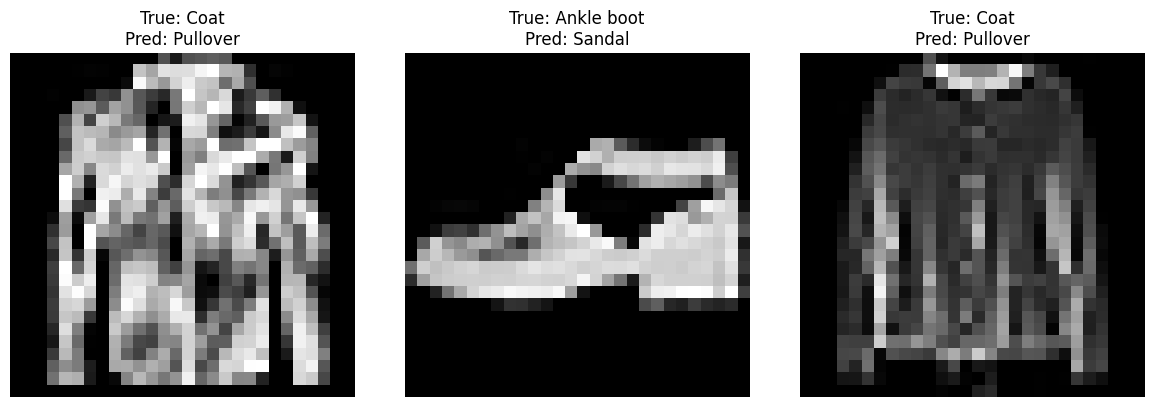

In [239]:
plt.figure(figsize=(12, 4))

for i, example in enumerate(wrong_examples):

    image = example["image"].squeeze().numpy()

    # Undo normalization
    image = image * 0.5 + 0.5

    plt.subplot(1, 3, i + 1)

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.title(
        f"True: {classes[example['true']]}\n"
        f"Pred: {classes[example['predicted']]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### 26. LOAD SAVED MODEL

In [240]:
saved_model_path = os.path.join(
    "model",
    f"{STUDENT_ID}.pth"
)

if os.path.exists(saved_model_path):

    loaded_model = CNN().to(device)

    loaded_model.load_state_dict(
        torch.load(
            saved_model_path,
            map_location=device
        )
    )

    loaded_model.eval()

    print(
        "Saved model loaded successfully!"
    )

else:

    print(
        "Saved model file is not currently "
        "present in the GitHub repository."
    )

Saved model loaded successfully!


### 27. CUSTOM IMAGE PREDICTION FUNCTION

In [241]:
def predict_custom_image(image_path, model):

    image = Image.open(image_path).convert("RGB")

    image_tensor = custom_transform(image)

    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0)

    image_tensor = image_tensor.to(device)

    model.eval()

    with torch.no_grad():

        output = model(image_tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        confidence, predicted_class = torch.max(
            probabilities,
            dim=1
        )

    predicted_index = predicted_class.item()

    confidence_percentage = (
        confidence.item() * 100
    )

    return (
        image,
        classes[predicted_index],
        confidence_percentage
    )

### 28. TEST ONE CUSTOM IMAGE

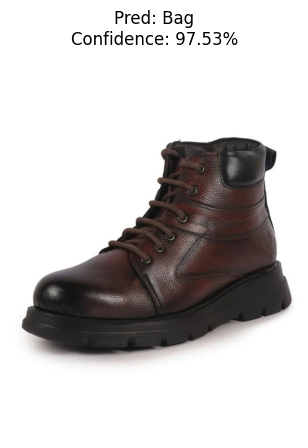

In [242]:
first_image = sorted(custom_files)[0]

image_path = os.path.join(
    custom_dir,
    first_image
)

image, prediction, confidence = (
    predict_custom_image(
        image_path,
        model
    )
)

plt.figure(figsize=(5, 5))

plt.imshow(image)

plt.title(
    f"Pred: {prediction}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()

### 29. PREDICT ALL CUSTOM IMAGES

In [243]:
results = []

for filename in sorted(custom_files):

    image_path = os.path.join(
        custom_dir,
        filename
    )

    image, prediction, confidence = (
        predict_custom_image(
            image_path,
            model
        )
    )

    results.append({
        "filename": filename,
        "image": image,
        "prediction": prediction,
        "confidence": confidence
    })

print(
    f"Predicted {len(results)} custom images."
)

for result in results:

    print(
        f"{result['filename']:25s} "
        f"→ {result['prediction']:15s} "
        f"({result['confidence']:.2f}%)"
    )

Predicted 10 custom images.
ankleboot.jpeg            → Bag             (97.53%)
bag.jpeg                  → Shirt           (32.98%)
coat.jpeg                 → Bag             (94.93%)
dress.jpeg                → Bag             (99.97%)
pullover.jpeg             → Bag             (100.00%)
sandal.jpeg               → Trouser         (98.86%)
shirt.jpeg                → Shirt           (49.20%)
sneaker.jpeg              → Bag             (100.00%)
trouser.jpeg              → Trouser         (94.58%)
tshirt.jpeg               → T-shirt/top     (69.70%)


### 30. CUSTOM PREDICTION GALLERY

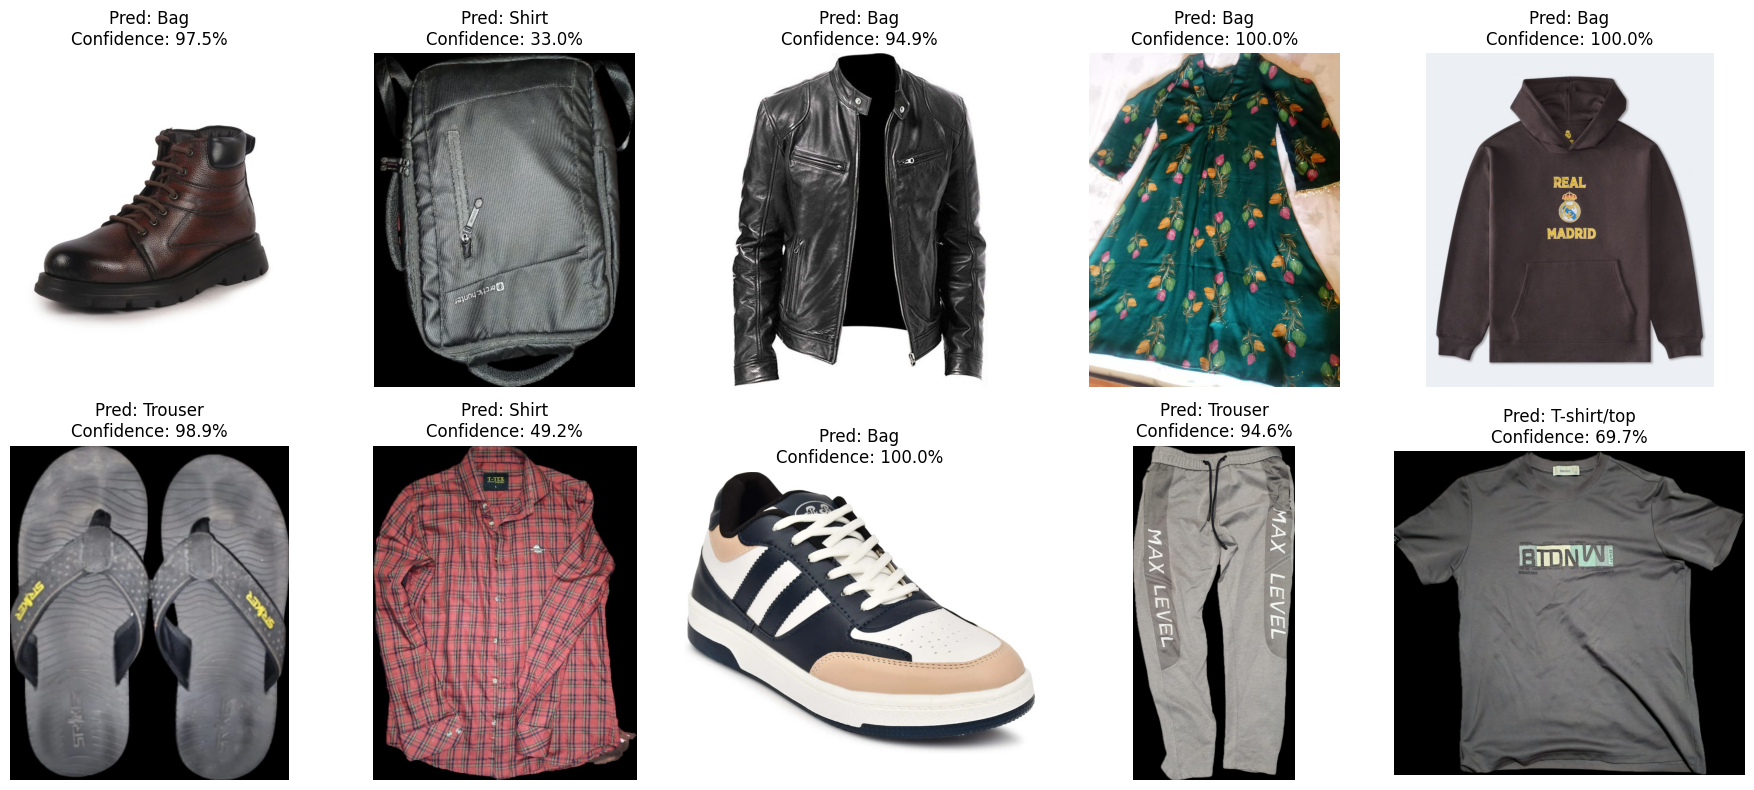

In [244]:
num_images = len(results)

columns = 5
rows = int(np.ceil(num_images / columns))

plt.figure(
    figsize=(18, 4 * rows)
)

for i, result in enumerate(results):

    plt.subplot(
        rows,
        columns,
        i + 1
    )

    plt.imshow(result["image"])

    plt.title(
        f"Pred: {result['prediction']}\n"
        f"Confidence: {result['confidence']:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### 31. CUSTOM RESULTS TABLE

In [245]:
import pandas as pd

results_table = pd.DataFrame([
    {
        "Image": r["filename"],
        "Predicted Class": r["prediction"],
        "Confidence (%)": round(
            r["confidence"],
            2
        )
    }
    for r in results
])

results_table

,Image,Predicted Class,Confidence (%)
0,ankleboot.jpeg,Bag,97.53
1,bag.jpeg,Shirt,32.98
2,coat.jpeg,Bag,94.93
3,dress.jpeg,Bag,99.97
4,pullover.jpeg,Bag,100.00
5,sandal.jpeg,Trouser,98.86
6,shirt.jpeg,Shirt,49.20
7,sneaker.jpeg,Bag,100.00
8,trouser.jpeg,Trouser,94.58
9,tshirt.jpeg,T-shirt/top,69.70


### 32. FINAL SUMMARY

In [246]:
print("=" * 60)
print("FASHIONMNIST CNN CLASSIFICATION - FINAL RESULTS")
print("=" * 60)

print(
    f"Training Accuracy   : "
    f"{train_accuracies[-1]:.2f}%"
)

print(
    f"Validation Accuracy : "
    f"{val_accuracies[-1]:.2f}%"
)

print(
    f"Test Accuracy       : "
    f"{test_accuracy:.2f}%"
)

print(
    f"Custom Images       : "
    f"{len(results)}"
)

print(
    f"Model File          : "
    f"{model_path}"
)

print("=" * 60)

FASHIONMNIST CNN CLASSIFICATION - FINAL RESULTS
Training Accuracy   : 96.80%
Validation Accuracy : 92.03%
Test Accuracy       : 91.14%
Custom Images       : 10
Model File          : model/210145.pth


### 33. List Model Directory Contents

In [248]:
model_path = "model/" + STUDENT_ID + ".pth"

print("Model path:", model_path)
print("Exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("Model size:", os.path.getsize(model_path), "bytes")

Model path: model/210145.pth
Exists: True
Model size: 1689983 bytes


In [249]:
from google.colab import files

files.download("model/210145.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>